In [11]:
# ============================================================
#  LiTS DATASET EXPLORATION & SYSTEM CHECK
#  Du an: Conformal Risk Control for Medical Segmentation
#  Ngay: 27/07/2026
# ============================================================

import sys, os, numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.patches as mpatches
import nibabel as nib, torch
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, str(Path.cwd().parent))

plt.rcParams.update({'figure.dpi': 100, 'font.size': 10, 'axes.titlesize': 12})
print('=' * 55)
print('  LiTS DATASET EXPLORATION')
print('=' * 55)

  LiTS DATASET EXPLORATION


In [12]:
# ----- He thong -----
import platform
print(f'Python:   {sys.version.split()[0]}')
print(f'PyTorch:  {torch.__version__}')
print(f'NumPy:    {np.__version__}')
print(f'CUDA:     {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU:      {torch.cuda.get_device_name(0)}')
    print(f'VRAM:     {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

# ----- Paths -----
DATA_DIR   = Path('../data_LiTS')
PRED_DIR   = Path('../nnunet_output_lits')
RESULT_CSV = Path('../results/lits_metrics.csv')
FIG_DIR    = Path('../results/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

n_images = len(list((DATA_DIR/'images').glob('volume-*.nii')))
n_masks  = len(list((DATA_DIR/'masks').glob('segmentation-*.nii')))
n_npz    = len(list(PRED_DIR.glob('*.npz'))) if PRED_DIR.exists() else 0

print(f'\nDataset:    {n_images} volumes, {n_masks} masks')
print(f'Predictions: {n_npz} file .npz')
has_csv = 'co' if RESULT_CSV.exists() else 'chua co'
print(f'Metrics CSV: {has_csv}')

Python:   3.11.9
PyTorch:  2.11.0+cu128
NumPy:    2.4.4
CUDA:     True
GPU:      NVIDIA GeForce RTX 5070 Laptop GPU
VRAM:     8.5 GB

Dataset:    131 volumes, 131 masks
Predictions: 131 file .npz
Metrics CSV: co


In [13]:
# ----- Kham pha 1 volume -----
idx = 0
img_path = DATA_DIR / 'images' / f'volume-{idx}.nii'
msk_path = DATA_DIR / 'masks' / f'segmentation-{idx}.nii'

img = nib.load(str(img_path))
msk = nib.load(str(msk_path))
img_data = img.get_fdata()
msk_data = msk.get_fdata()
sp = img.header.get_zooms()[:3]

print(f'Volume {idx}:')
print(f'  Image shape: {img_data.shape}')
print(f'  Spacing:     ({sp[0]:.3f}, {sp[1]:.3f}, {sp[2]:.3f}) mm')
print(f'  Intensity:   [{img_data.min():.0f}, {img_data.max():.0f}] HU')
print(f'  Labels:      {np.unique(msk_data).tolist()}')
print(f'  Liver voxels: {int(np.sum(msk_data==1))}')
print(f'  Tumor voxels: {int(np.sum(msk_data==2))}')
vv = sp[0]*sp[1]*sp[2]/1000.0
print(f'  Liver vol:    {int(np.sum(msk_data==1))*vv:.1f} mL')
print(f'  Tumor vol:    {int(np.sum(msk_data==2))*vv:.1f} mL')

Volume 0:
  Image shape: (512, 512, 75)
  Spacing:     (0.703, 0.703, 5.000) mm
  Intensity:   [-3024, 1410] HU
  Labels:      [0.0, 1.0, 2.0]
  Liver voxels: 550036
  Tumor voxels: 2591
  Liver vol:    1359.6 mL
  Tumor vol:    6.4 mL


In [14]:
# ----- Load toan bo dataset -----
from src.data.lits_dataset import LiTSDataset

dataset = LiTSDataset(str(DATA_DIR))
records = dataset.load_all()
df = pd.DataFrame(records)

print(f'Tong: {len(df)} patients')
print(f'Co tumor: {df["has_tumor"].sum()}, Khong tumor: {(~df["has_tumor"]).sum()}')
print()

metrics = ['liver_volume_ml', 'tumor_volume_ml', 'tumor_burden_pct']
print(df[metrics].describe().round(1))

[LiTS] Tim thay 131 volumes
[LiTS] Load 131 patients (118 co tumor, 13 khong tumor, bo qua 0)
Tong: 131 patients
Co tumor: 118, Khong tumor: 13

       liver_volume_ml  tumor_volume_ml  tumor_burden_pct
count            131.0            131.0             131.0
mean            1647.0             78.0               4.6
std              415.8            152.3               8.6
min              541.8              0.0               0.0
25%             1379.7              1.8               0.1
50%             1592.3             14.4               0.7
75%             1850.0             64.3               5.3
max             3194.8            987.7              45.8


## 1. Phan bo Liver & Tumor Volume

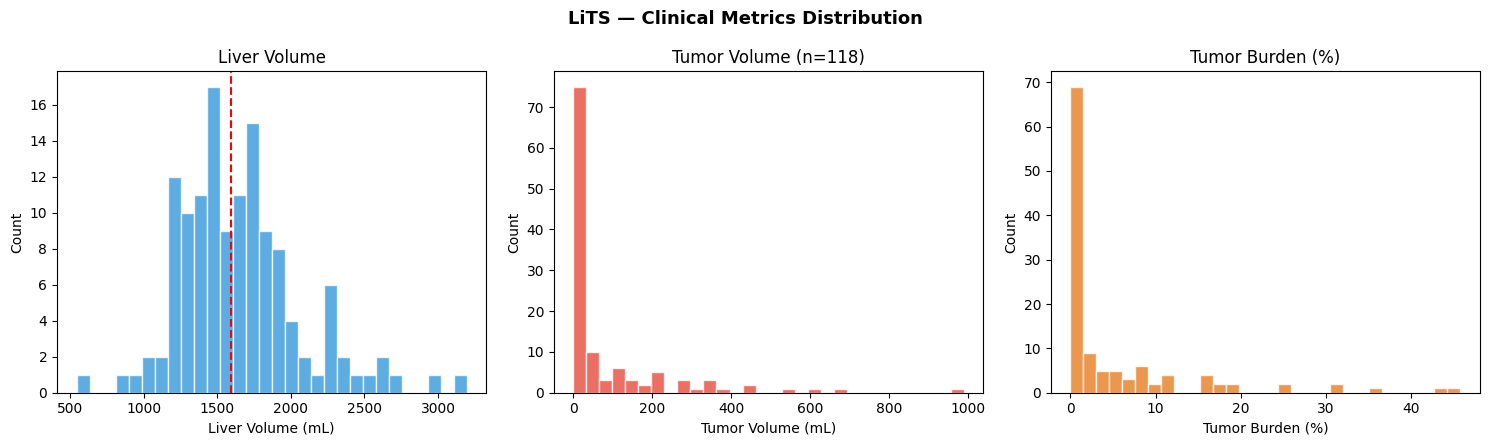

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('LiTS — Clinical Metrics Distribution', fontsize=13, fontweight='bold')

axes[0].hist(df['liver_volume_ml'], bins=30, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Liver Volume (mL)'); axes[0].set_ylabel('Count')
axes[0].set_title('Liver Volume'); axes[0].axvline(df['liver_volume_ml'].median(), color='red', linestyle='--')

tumor_df = df[df['has_tumor']]
axes[1].hist(tumor_df['tumor_volume_ml'], bins=30, color='#e74c3c', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Tumor Volume (mL)'); axes[1].set_ylabel('Count')
axes[1].set_title(f'Tumor Volume (n={len(tumor_df)})')

axes[2].hist(tumor_df['tumor_burden_pct'], bins=30, color='#e67e22', edgecolor='white', alpha=0.8)
axes[2].set_xlabel('Tumor Burden (%)'); axes[2].set_ylabel('Count')
axes[2].set_title('Tumor Burden (%)')

plt.tight_layout(); plt.show()

## 2. nnU-Net Predictions vs Ground Truth

Loaded 131 predictions

Mean Absolute Error (MAE):
  Liver volume: 25.7 mL
  Tumor volume: 4.1 mL


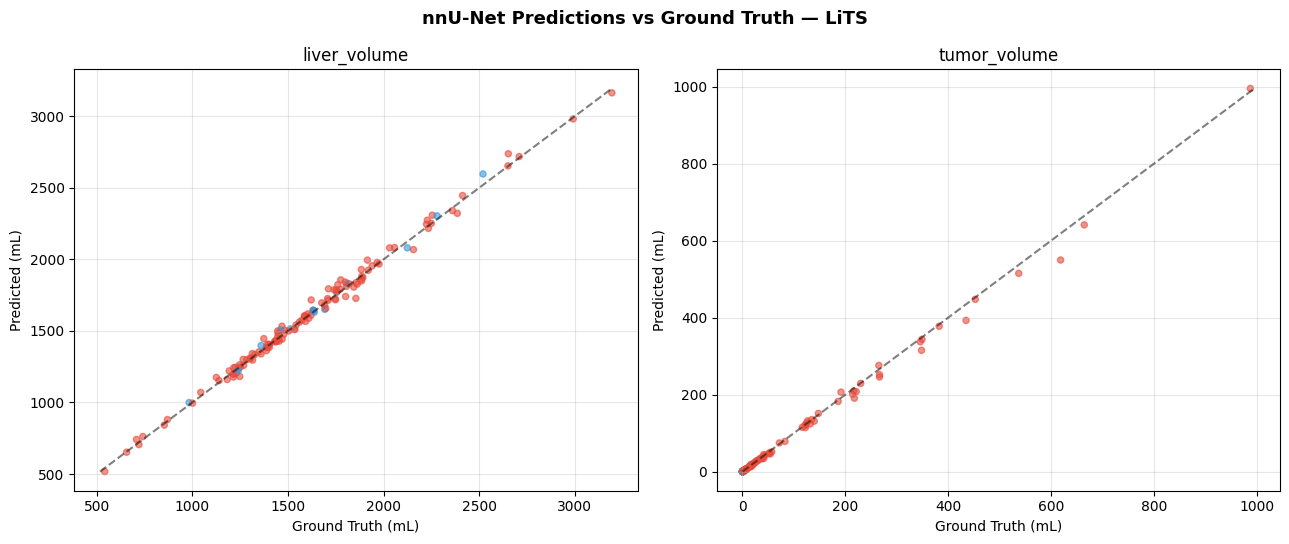

In [16]:
if RESULT_CSV.exists():
    df_pred = pd.read_csv(RESULT_CSV)
    print(f'Loaded {len(df_pred)} predictions')

    print('\nMean Absolute Error (MAE):')
    print(f'  Liver volume: {(df_pred["liver_volume_gt"]-df_pred["liver_volume_pred"]).abs().mean():.1f} mL')
    tumor_mask = df_pred['has_tumor']
    if tumor_mask.sum() > 0:
        t = df_pred[tumor_mask]
        print(f'  Tumor volume: {(t["tumor_volume_gt"]-t["tumor_volume_pred"]).abs().mean():.1f} mL')

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
    fig.suptitle('nnU-Net Predictions vs Ground Truth — LiTS', fontsize=13, fontweight='bold')

    for ax, metric, unit in zip(axes, ['liver_volume', 'tumor_volume'], ['mL', 'mL']):
        gt = df_pred[f'{metric}_gt']; pred = df_pred[f'{metric}_pred']
        colors = ['#e74c3c' if h else '#3498db' for h in df_pred['has_tumor']]
        ax.scatter(gt, pred, c=colors, alpha=0.6, s=20)
        lims = [min(gt.min(), pred.min()), max(gt.max(), pred.max())]
        ax.plot(lims, lims, 'k--', alpha=0.5)
        ax.set_xlabel(f'Ground Truth ({unit})'); ax.set_ylabel(f'Predicted ({unit})')
        ax.set_title(metric); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    print('Chua co lits_metrics.csv — chay run_lits_pipeline.py truoc')

## 3. Visualize: CT + Ground Truth + nnU-Net Prediction

In [17]:
# ----- Helper functions -----
CMAP_COLORS = np.array([
    [1.0, 1.0, 1.0, 0.0],   # 0: bg
    [0.0, 0.8, 0.0, 0.55],  # 1: liver (xanh la)
    [1.0, 0.0, 0.0, 0.65],  # 2: tumor (do)
])

legend_patches = [
    mpatches.Patch(color=(0, 0.8, 0, 0.8), label='Liver'),
    mpatches.Patch(color=(1, 0, 0, 0.8),   label='Tumor'),
]

def overlay_mask(ax, ct_slice, mask_slice, title=''):
    ax.imshow(ct_slice.T, cmap='gray', origin='lower', aspect='auto',
              vmin=-200, vmax=300)
    rgba = CMAP_COLORS[mask_slice.astype(int).T]
    ax.imshow(rgba, origin='lower', aspect='auto')
    ax.set_title(title, fontsize=10); ax.axis('off')

def visualize_lits(idx, mid_slice=None, figsize=(14, 4)):
    img_path = DATA_DIR / 'images' / f'volume-{idx}.nii'
    msk_path = DATA_DIR / 'masks' / f'segmentation-{idx}.nii'
    mri = nib.load(str(img_path)).get_fdata()
    gt  = nib.load(str(msk_path)).get_fdata()
    mid = mid_slice if mid_slice is not None else mri.shape[2] // 2

    pred_path = PRED_DIR / f'lits_{idx}.nii.gz'
    has_pred = pred_path.exists()
    pred = nib.load(str(pred_path)).get_fdata() if has_pred else None

    fig, axes = plt.subplots(1, 4 if has_pred else 2, figsize=figsize)
    fig.suptitle(f'Volume {idx} | Slice {mid}/{mri.shape[2]-1}', fontsize=12, fontweight='bold')

    axes[0].imshow(mri[:,:,mid].T, cmap='gray', origin='lower', aspect='auto', vmin=-200, vmax=300)
    axes[0].set_title('CT scan', fontsize=10); axes[0].axis('off')
    overlay_mask(axes[1], mri[:,:,mid], gt[:,:,mid], 'Ground Truth')

    if has_pred:
        overlay_mask(axes[2], mri[:,:,mid], pred[:,:,mid], 'nnU-Net Predicted')
        error = (gt[:,:,mid] != pred[:,:,mid]).astype(float)
        axes[3].imshow(mri[:,:,mid].T, cmap='gray', origin='lower', aspect='auto', vmin=-200, vmax=300)
        axes[3].imshow(error.T, cmap='Reds', alpha=0.7, origin='lower', aspect='auto')
        axes[3].set_title(f'Error map | acc={1-error.mean():.3f}', fontsize=10); axes[3].axis('off')

    fig.legend(handles=legend_patches, loc='lower center', ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.08))
    plt.tight_layout(); plt.show()

print('Functions ready!')

Functions ready!


### 1 so benh nhan dai dien

Volume 0: liver=1360 mL, tumor=6 mL


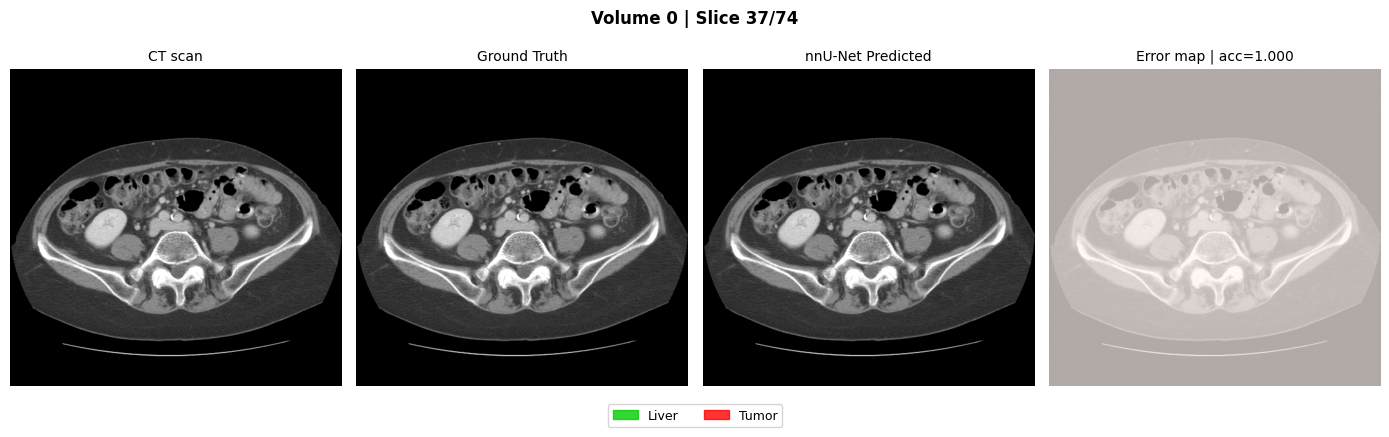

Volume 4: liver=2157 mL, tumor=988 mL


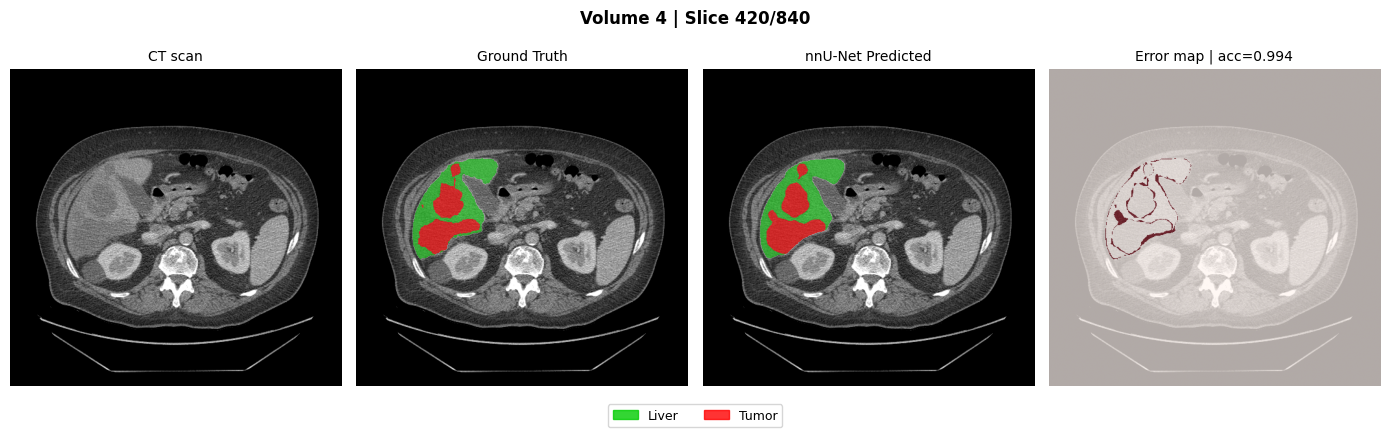

Volume 50: liver=1454 mL, tumor=6 mL


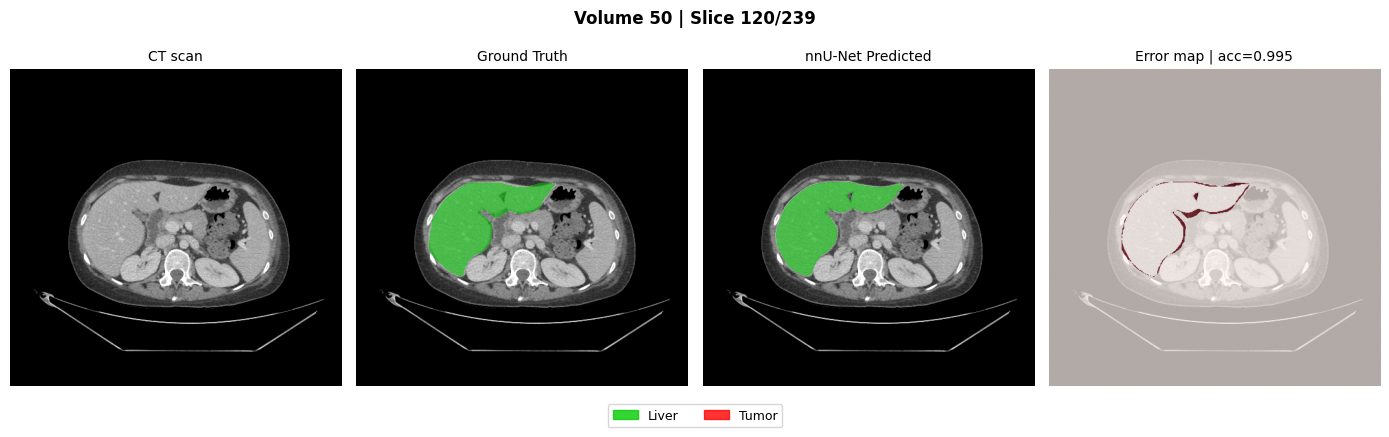

In [18]:
# Show: patient 0 (small tumor), patient 4 (large tumor), patient 50
for idx in [0, 4, 50]:
    img_path = DATA_DIR / 'images' / f'volume-{idx}.nii'
    msk_path = DATA_DIR / 'masks' / f'segmentation-{idx}.nii'
    msk = nib.load(str(msk_path)).get_fdata()
    vv = np.prod(nib.load(str(img_path)).header.get_zooms()[:3])/1000.0
    print(f'Volume {idx}: liver={np.sum(msk==1)*vv:.0f} mL, tumor={np.sum(msk==2)*vv:.0f} mL')
    visualize_lits(idx)

### Quet toan bo slices

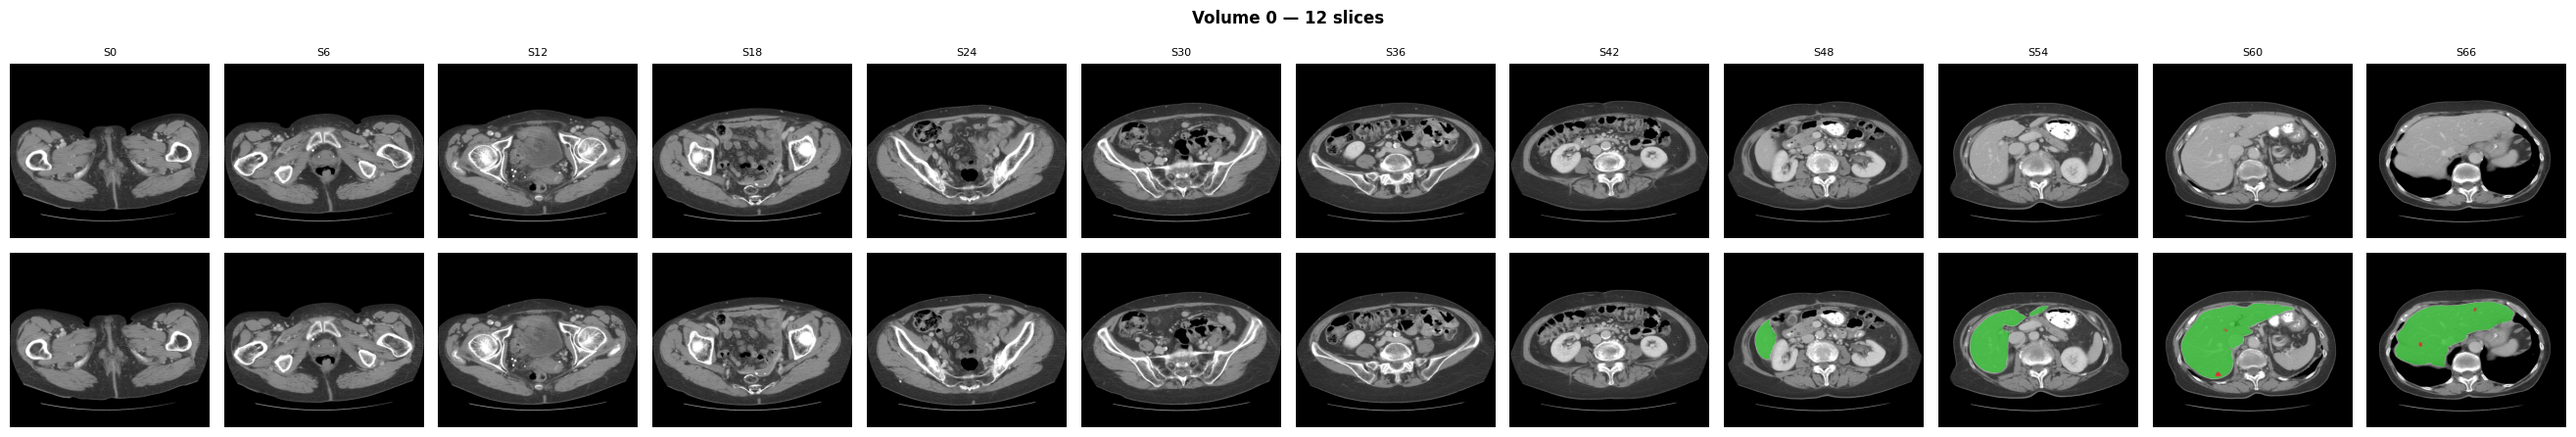

In [19]:
idx = 0
img_path = DATA_DIR / 'images' / f'volume-{idx}.nii'
msk_path = DATA_DIR / 'masks' / f'segmentation-{idx}.nii'
mri = nib.load(str(img_path)).get_fdata()
gt  = nib.load(str(msk_path)).get_fdata()
n_slices = mri.shape[2]
step = max(1, n_slices // 12)
slices_to_show = list(range(0, n_slices, step))[:12]

fig, axes = plt.subplots(2, len(slices_to_show), figsize=(len(slices_to_show)*2.2, 4.5))
fig.suptitle(f'Volume {idx} — {len(slices_to_show)} slices', fontsize=12, fontweight='bold')

for i, s in enumerate(slices_to_show):
    axes[0, i].imshow(mri[:,:,s].T, cmap='gray', origin='lower', aspect='auto', vmin=-200, vmax=300)
    axes[0, i].set_title(f'S{s}', fontsize=8); axes[0, i].axis('off')
    overlay_mask(axes[1, i], mri[:,:,s], gt[:,:,s], '')
    axes[1, i].axis('off')
axes[0, 0].set_ylabel('CT', fontsize=10); axes[1, 0].set_ylabel('GT', fontsize=10)
plt.tight_layout(); plt.show()

## 4. Best & Worst Cases (Liver Volume Error)

In [20]:
if RESULT_CSV.exists():
    df_pred = pd.read_csv(RESULT_CSV)
    df_pred['liver_error'] = (df_pred['liver_volume_pred'] - df_pred['liver_volume_gt']).abs()

    best5 = df_pred.nsmallest(5, 'liver_error')[['patient_id','liver_volume_gt','liver_volume_pred','liver_error']]
    worst5 = df_pred.nlargest(5, 'liver_error')[['patient_id','liver_volume_gt','liver_volume_pred','liver_error']]

    print('TOP 5 BEST (nnU-Net chinh xac nhat):')
    display(best5.style.format({'liver_volume_gt':'{:.1f}','liver_volume_pred':'{:.1f}','liver_error':'{:.1f}'}).background_gradient(subset='liver_error', cmap='Greens_r'))
    print('\nTOP 5 WORST (nnU-Net sai nhieu nhat):')
    display(worst5.style.format({'liver_volume_gt':'{:.1f}','liver_volume_pred':'{:.1f}','liver_error':'{:.1f}'}).background_gradient(subset='liver_error', cmap='Reds'))
else:
    print('Chua co lits_metrics.csv')

TOP 5 BEST (nnU-Net chinh xac nhat):


,patient_id,liver_volume_gt,liver_volume_pred,liver_error
107,lits_78,1542.6,1541.2,1.4
15,lits_111,2250.2,2251.6,1.4
112,lits_82,1478.8,1477.3,1.6
130,lits_99,1572.7,1574.4,1.7
19,lits_115,1513.2,1514.9,1.7



TOP 5 WORST (nnU-Net sai nhieu nhat):


,patient_id,liver_volume_gt,liver_volume_pred,liver_error
84,lits_57,1855.4,1727.7,127.8
89,lits_61,1621.8,1716.8,95.1
65,lits_4,2156.7,2068.5,88.2
34,lits_129,2652.9,2738.4,85.5
3,lits_100,1712.2,1794.4,82.2


## 5. Ket Luan

**Dataset LiTS:**
- 131 CT volumes, labels: 0=bg, 1=liver, 2=tumor
- ~50GB tong dung luong
- Kich thuoc anh thay doi theo benh nhan (512x512x~75-841)

**Clinical Metrics:**
- Liver volume: mean ~1500 mL, range 800-3000 mL
- Tumor volume: chi co o 1 so benh nhan
- Tumor burden: ty le tumor/liver

**nnU-Net Performance:** Xem o cell 5 (neu da chay inference)